# Mediznische Hochschule Hannover - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Medizinische Hochschule Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/00f2yqf98' -- 'Medizinische Hochschule Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Medizinische Hochschule Hannover,"5Children's Hospital AUF DER BULT, Hannover Me...",https://openalex.org/W4225015048
1,not assigned,Medizinische Hochschule Hannover,"Department of Urology, Hannover Medical School...",https://openalex.org/W4282045829
2,not assigned,Medizinische Hochschule Hannover,"Hannover Herzrhythmus Centrum, Klinik für Kard...",https://openalex.org/W4285035303
3,not assigned,Medizinische Hochschule Hannover,"Klinik für Kardiologie und Angiologie, Medizin...",https://openalex.org/W4285035303
4,not assigned,Medizinische Hochschule Hannover,"Hannover Medical School, and German Center for...",https://openalex.org/W4205667236


In [292]:
MAPPING_DICT = {
    'Exzellenzcluster RESIST': ['resist'],
    'Forschungs- und Lehreinheit Hebammenwissenschaft': ['hebammenwissenschaft', 'midwifery'],
    #'Hannover Biomedical Research School': [],
    'Hannover Unified Biobank (HUB)': ['biobank'],
    'Institut für Allgemeinmedizin und Palliativmedizin': ['palliativ', 'allgemeinmedizin', 'general practice'],
    'Institut für Molekulare Bakteriologie': ['bacteriology'],
    'Institut für Molekulare und Translationale Therapiestrategien': ['therapeutic strategies'],
    'Institut für Sportmedizin': ['sports medicine'],
    'Institut für Transplantationsimmunologie': ['transplant immunology'],
    'Institut für Zelltherapeutika': ['(ctc)', 'cellular therapeutics'],
    #'Integriertes Forschungs- und Behandlungszentrum Transplantation (IFB-Tx)': [],
    #'Interdisziplinäres Zentrum für Gesichtsfehlbildungen': [],
    'Klinik für Anästhesiologie und Intensivmedizin': ['an(e|ae|ä)sthesiolog(ie|y)', 'intensivmedizin'],
    'Klinik für Dermatologie, Allergologie und Venerologie': ['dermatolog(ie|y)', 'allergy'],
    'Klinik für Frauenheilkunde und Geburtshilfe': ['obstetrics', 'rehabilitati(ve|on)', 'gyn(ae|e)cology', 'frauenheilkunde'],
    #'Klinik für Rehabilitationsmedizin': [],
    #'Kopf-Hals-Tumorzentrum Hannover': [],
    'Leibniz Forschungslaboratorien für Biotechnologie und künstliche Organe (LEBAO)': ['(lebao)'],
    'REBIRTH - Forschungszentrum für translationale regenerative Medizin': ['regenerative', 'rebirth cluster'],
    'Research Core Unit for Laser Microscopy': ['laser microscopy'],
    'Twincore': ['twincore'], # selbst ergänzt
    'Zentralapotheke': ['apotheke'],
    'Zentrale Forschungseinrichtung Elektronenmikroskopie': ['electron microscopy'],
    'Zentrale Forschungseinrichtung Genomics': ['genomics'],
    #'Zentrale Forschungswerkstätten': [],
    'Zentrum Anatomie und Zellbiologie': ['applied anatomy', 'neuroanatomy'],
    'Zentrum Augenheilkunde, Hals-Nasen-Ohrenheilkunde, Phoniatrie und Pädaudiologie': ['otorhinolaryngology', 'otol(ogy|ar(yn|ny)gology)', 
                                                                                        'hals-(, )?nasen', 'ophthalmology', 'hno-klinik',
                                                                                        'augenklinik', 'eye hospital'
                                                                                       ],
    'Zentrum Biochemie': ['(cell|clinical) biochemistry', 'biophysical chemistry', 'zellbiochemie'],
    'Zentrum Biometrie, Medizinische Informatik und Medizintechnik': ['informatics', 'biostatistics'],
    'Zentrum Chirurgie': ['of urology', 'vas(cu|uc)lar', 'plasti(sch|c)', 'trauma', 'orthop(ae|e)dic', 'orthopädische klinik', 'unfallchirurgi(e|sche)',
                          'visceral', 'surgical', 'viszeral', 'thorax', 'kinderchirurgie', 'biomechanics', 'klinik für urologie'
                         ],
    #'Zentrum für Arzneimittelsicherheit (ZAS)': [],
    'Zentrum für Kinderheilkunde und Jugendmedizin': ['respiratory', 'pulmon(ology|ary)', 'metabolic', 'p(ae|e|ä)diatri(c|sche)', 'pneumolog(ie|y)',
                                                      'cardiothoracic surgery', 'kinderklinik', "children's hospital", 'kinderheilkunde'
                                                     ],
    'Zentrum für Klinische Studien (ZKS)': ['(zks)', 'cent(re|er) for clinical trials'],
    'Zentrum für Neurologische Medizin': ['neurolog(ie|y)', 'neurosurgery'],
    'Zentrum für Pathologie, Forensik und Genetik': ['patholog(ie|y)', 'human genetics', 'humangenetik'],
    'Zentrum für Pharmakologie und Toxikologie': ['toxicology', 'pharma(k|c)olog(ie|y)', 'metabolomics'],
    'Zentrum für Radiologie': ['radiolog(ie|y)', 'radiotherapy', 'nuclear', 'radiation', 'strahlentherapie'],
    'Zentrum für Seelische Gesundheit': ['psychiatr(ie|y)', 'psychosomati(k|c)', 'psychotherapy', 'neuroscience'],
    'Zentrum für Zahn-, Mund- und Kieferheilkunde': ['dentistry', 'maxillofacial', 'zahnerhaltung', 'gesichtschirurgie'],
    'Zentrum Innere Medizin': ['h(ä|e)matolog(ie|y)', 'hepatolog(ie|y)', 'angiolog(ie|y)', 'rheumatolog(ie|y)', 'hochdruckerkrankungen', 
                               'hypertension', 'gastroenterology', 'nephrology', 'cardiology dept', 'department of cardiology'
                              ],
    'Zentrum Laboratoriumsmedizin': ['virology', '(for|of) immunology', 'molecular biology', 'animal', 'transfusion medicine',
                                     'clinical chemistry', 'immunomorphology',
                                    ],
    'Zentrum Physiologie': ['neurophysiology', 'cell physiology'],
    'Zentrum Öffentliche Gesundheitspflege': ['philosoph(ie|y)', 'epidemiolog(ie|y)', 'so(z|c)iolog(ie|y)', 'social medicine', 'medical psychology',
                                              'public health', 'medizinische psychologie' 
                                             ]
}

In [293]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [294]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [295]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Zentrum für Kinderheilkunde und Jugendmedizin,Medizinische Hochschule Hannover,"5Children's Hospital AUF DER BULT, Hannover Me...",https://openalex.org/W4225015048
1,Zentrum Chirurgie,Medizinische Hochschule Hannover,"Department of Urology, Hannover Medical School...",https://openalex.org/W4282045829
2,Zentrum Innere Medizin,Medizinische Hochschule Hannover,"Hannover Herzrhythmus Centrum, Klinik für Kard...",https://openalex.org/W4285035303
3,Zentrum Innere Medizin,Medizinische Hochschule Hannover,"Klinik für Kardiologie und Angiologie, Medizin...",https://openalex.org/W4285035303
4,None,Medizinische Hochschule Hannover,"Hannover Medical School, and German Center for...",https://openalex.org/W4205667236
...,...,...,...,...
29965,Zentrum Laboratoriumsmedizin,Medizinische Hochschule Hannover,"Institute for Laboratory Animal Science, Hanno...",https://openalex.org/W3209933378
29966,Leibniz Forschungslaboratorien für Biotechnolo...,Medizinische Hochschule Hannover,"Department of Cardiac, Thoracic, Transplantati...",https://openalex.org/W3153405296
29967,Klinik für Anästhesiologie und Intensivmedizin,Medizinische Hochschule Hannover,Klinik für Anästhesiologie und Intensivmedizin...,https://openalex.org/W4200461277
29968,Zentrum Öffentliche Gesundheitspflege,Medizinische Hochschule Hannover,Institute of Medical Microbiology and Hospital...,https://openalex.org/W4244001713


In [296]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()[20:40]

array(['Medical University of Hannover, Hannover, Germany',
       'Hannover Medical School, Braunschweig, Germany',
       '4Hannover Medical School, Department of Haematology, Hemostasis, Oncology and Stem Cell Transplantation, Hannover, Germany',
       'Hannover Medical School, 30625 Hannover, Germany',
       'Department of Microbial Immune Regulation, Helmholtz Centre for Infection Research, 38124 Braunschweig, Germany; Hannover Medical School, 30625 Hannover, Germany',
       'Inflammation Research Group, Hannover Medical School, 30625 Hannover, Germany',
       'Institut für Medizinische                     Psychologie, Medizinische Hochschule Hannover, Hannover,                         Deutschland',
       'Department for Educational and Scientific IT Systems, Centre for Information Management, Hannover Medical School, 30625 Hannover, Germany',
       '3Hannover Medical School, Hannover, Germany;',
       'German Center for Lung Research, Biomedical Research in Endstage and Ob

In [297]:
df_with_inst[df_with_inst.inst_name.isnull()].groupby('raw_affiliation_string')['openalex_id'].count().reset_index().sort_values(by='openalex_id', ascending=False)[60:80]

,raw_affiliation_string,openalex_id
1764,"Medizinische Hochschule Hannover, Institut für...",6
58,"6Hannover Medical School, Hannover, Germany",6
671,"Department of Orthodontics, Hannover Medical S...",6
926,Hannover Medical School and German Centre for ...,6
965,"Hannover Medical School, Carl-Neuberg-Str. 1, ...",6
1741,"Medizinische Hochschule Hannover, Hanover, NDS...",6
1888,"Medizinische Hochschule, Hannover, Germany;",5
1616,Medizinische Hochschule Hannover = Hannover Me...,5
1682,"Medizinische Hochschule Hannover, Deutsches Hö...",5
2016,"Skin Cancer Center, Hannover Medical School, H...",5


In [298]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Exzellenzcluster RESIST,811
1,Forschungs- und Lehreinheit Hebammenwissenschaft,80
2,Hannover Unified Biobank (HUB),69
3,Institut für Allgemeinmedizin und Palliativmed...,399
4,Institut für Molekulare Bakteriologie,23
5,Institut für Molekulare und Translationale The...,317
6,Institut für Sportmedizin,108
7,Institut für Transplantationsimmunologie,159
8,Institut für Zelltherapeutika,53
9,Klinik für Anästhesiologie und Intensivmedizin,325


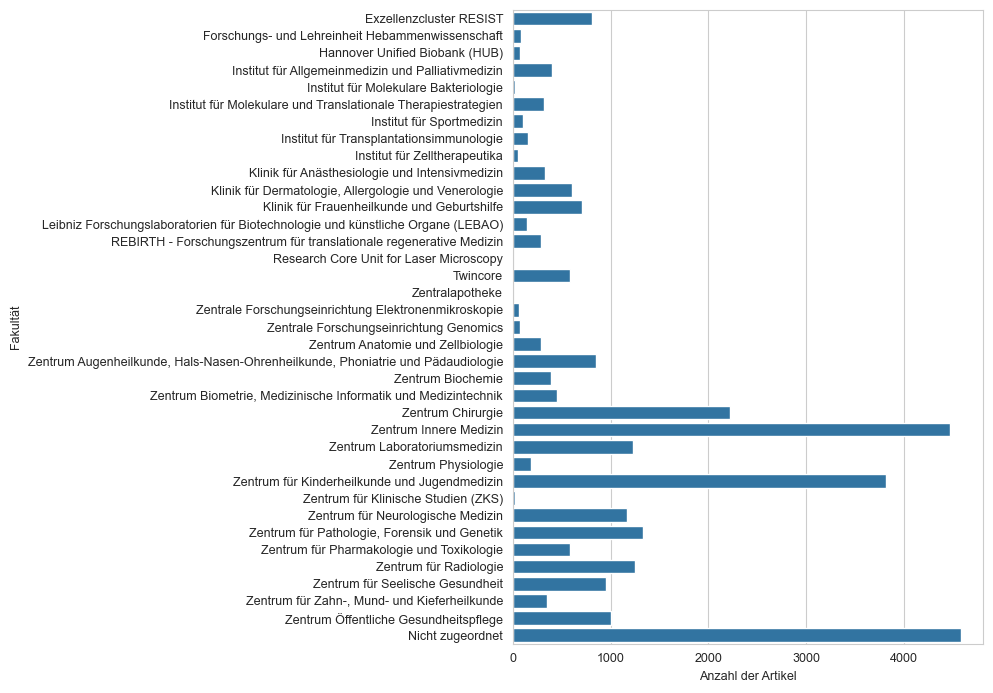

In [299]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [300]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8472472472472472